# 🤖 Phase 2: Predictive Analytics & Machine Learning
**Agritech Decision Intelligence: Lettuce Yield Optimization**

> **🇬🇧 EN:** Building upon the clean artifact from Phase 1, we benchmark a standard Linear Regression model against a Random Forest Regressor to prove that tree-based algorithms are required to map non-linear biochemical thresholds. The highest-performing model is serialized for prescriptive deployment, and an Executive Dashboard is generated to translate algorithmic outputs into business insights.
>
> **🇲🇽 ES:** Partiendo del artefacto limpio de la Fase 1, comparamos un modelo de Regresión Lineal estándar contra un Random Forest Regressor para probar que los algoritmos basados en árboles son necesarios para mapear umbrales bioquímicos no lineales. El modelo de mayor rendimiento se serializa para su despliegue prescriptivo, y se genera un Dashboard Ejecutivo para traducir los resultados algorítricos en insights de negocio.

In [2]:
# 1. Imports, Environment & MLOps Logging Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import joblib
import logging
import os
import shap

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Configure MLOps Logger for Model Training
log_dir = '../logs/'
os.makedirs(log_dir, exist_ok=True)
logging.basicConfig(
    filename=os.path.join(log_dir, 'ml_pipeline.log'),
    level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s'
)
logging.info("--- Phase 2: Predictive Modeling Initialized ---")
print("✅ Libraries loaded. MLOps Logging active (/logs/ml_pipeline.log).")

# 2. Data Ingestion
try:
    df = pd.read_csv('../data/processed/lettuce_growth_clean.csv')
    print(f"✅ Clean dataset loaded successfully. Shape: {df.shape}")
except FileNotFoundError:
    df = pd.read_csv('lettuce_growth_clean.csv')
    print(f"✅ Clean dataset loaded from local root. Shape: {df.shape}")

✅ Libraries loaded. MLOps Logging active (/logs/ml_pipeline.log).
✅ Clean dataset loaded successfully. Shape: (4900, 9)


## 🧩 1. Feature Selection & Data Partitioning
**🇬🇧 EN:** We isolate our independent variables from the target (`Yield_g`). A strict 80/20 train-test split is applied to prevent data leakage and ensure our model generalizes well to unseen data.
**🇲🇽 ES:** Aislamos nuestras variables independientes del objetivo (`Yield_g`). Se aplica una partición estricta 80/20 de entrenamiento y prueba para prevenir fuga de datos y asegurar que nuestro modelo generalice bien ante datos no vistos.

In [4]:
features = ['Temperature_C', 'Humidity_percent', 'pH_Level', 'Nutrient_EC_mS', 'Light_Hours', 'Growth_Days']
target = 'Yield_g'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
logging.info(f"Data partitioned. Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train/Test split complete: {X_train.shape[0]} train samples, {X_test.shape[0]} test samples.")

Train/Test split complete: 3920 train samples, 980 test samples.


## 📉 2. Baseline Modeling: The Linear Fallacy
**🇬🇧 EN:** Mathematical demonstration of linear models failing to capture complex biological curves. Because crop yield decays rapidly when moving away from the optimal pH, a straight line will inevitably underfit the operational reality.
**🇲🇽 ES:** Demostración matemática del fracaso de los modelos lineales para capturar curvas biológicas complejas. Dado que el rendimiento cae rápidamente al alejarse del pH óptimo, una línea recta inevitablemente subajustará la realidad operativa.

In [6]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

logging.info(f"Baseline Linear Regression -> R2: {lr_r2:.4f}, RMSE: {lr_rmse:.2f}")
print("--- Baseline Model: Linear Regression ---")
print(f"R-squared (R2): {lr_r2:.4f}")
print(f"RMSE: {lr_rmse:.2f} grams")

--- Baseline Model: Linear Regression ---
R-squared (R2): 0.0019
RMSE: 100.30 grams


## 🌲 3. Advanced Ensembles: Random Forest Regressor
**🇬🇧 EN:** Utilizing multiple decision trees to accurately map non-linear biochemical decay and optimization zones. Tree-based models can inherently split the dataset at precise biological thresholds (e.g., exactly at pH 6.0).
**🇲🇽 ES:** Utilización de múltiples árboles de decisión para mapear con precisión el decaimiento bioquímico no lineal y las zonas de optimización. Los modelos basados en árboles pueden dividir intrínsecamente el dataset en umbrales biológicos precisos (ej. exactamente en pH 6.0).

In [8]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

logging.info(f"Advanced Random Forest -> R2: {rf_r2:.4f}, RMSE: {rf_rmse:.2f}")
print("--- Advanced Model: Random Forest ---")
print(f"R-squared (R2): {rf_r2:.4f}")
print(f"RMSE: {rf_rmse:.2f} grams")
print(f"\n[Success] Accuracy improvement over baseline: +{(rf_r2 - lr_r2)*100:.1f} percentage points.")

--- Advanced Model: Random Forest ---
R-squared (R2): 0.9452
RMSE: 23.51 grams

[Success] Accuracy improvement over baseline: +94.3 percentage points.


## ⚖️ 4. Executive Dashboard: Model Validation & Biological Thresholds
**🇬🇧 EN:** A predictive model is merely a black box without transparent interpretability. To translate our Machine Learning results into actionable business insights, we generate a comprehensive Decision Intelligence Dashboard. This UI-optimized panel unpacks the algorithmic logic by revealing the primary predictive drivers, mapping the exact non-linear biological thresholds where crop yield maximizes, and visually validating the model's precision.

**🇲🇽 ES:** Un modelo predictivo es simplemente una caja negra sin interpretabilidad transparente. Para traducir nuestros resultados de Machine Learning en insights de negocio procesables, generamos un Dashboard de Inteligencia de Decisiones. Este panel optimizado para UI desempaqueta la lógica algorítmica revelando los principales impulsores predictivos, mapeando los umbrales biológicos no lineales donde se maximiza el rendimiento, y validando visualmente la precisión del modelo.

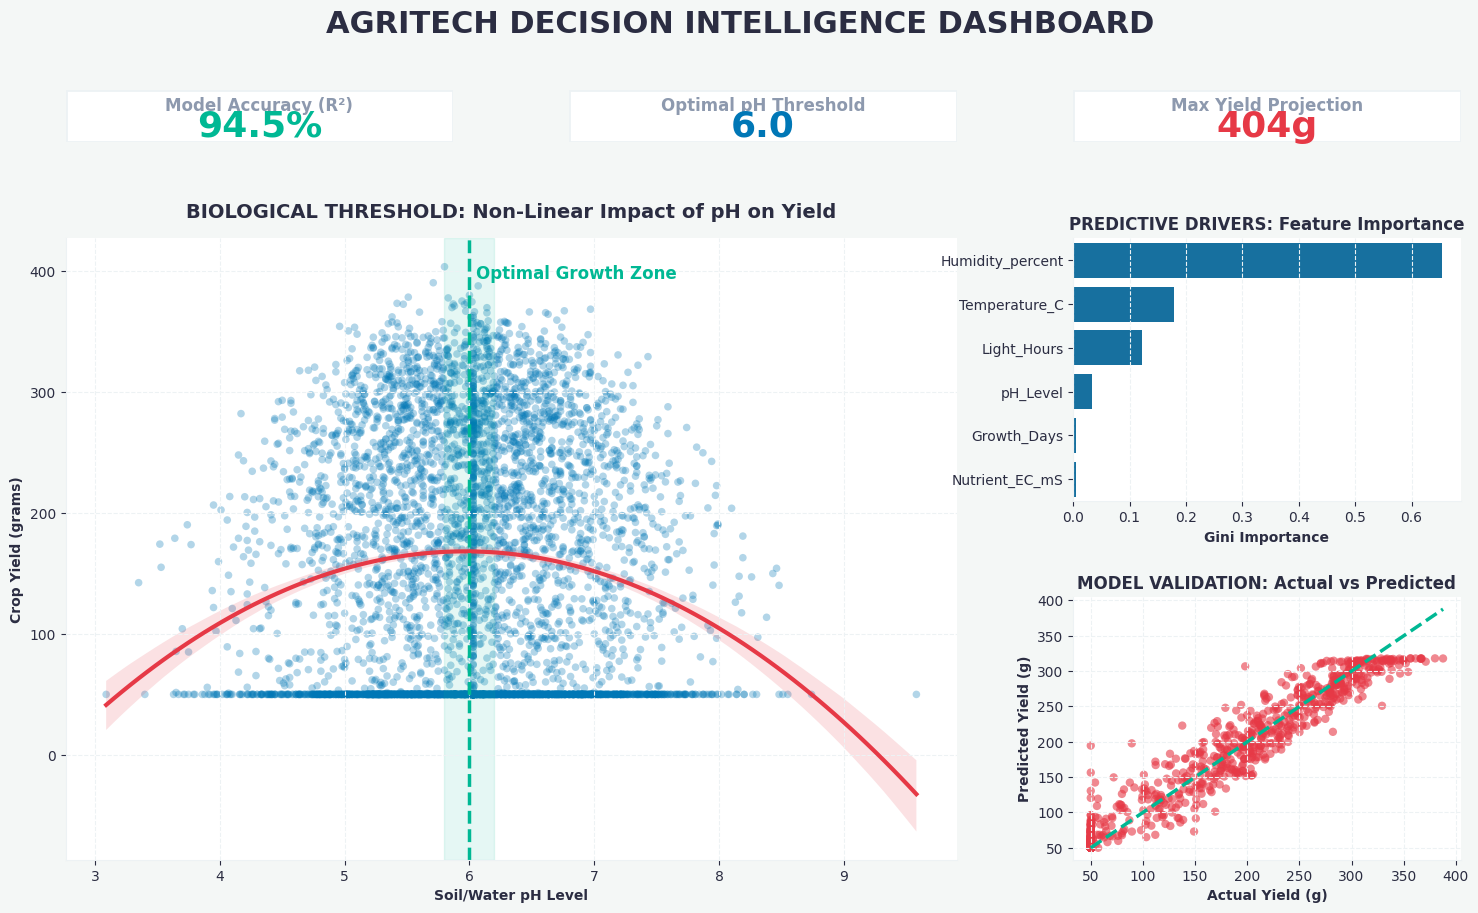

✅ Dashboard generated and saved to: ../reports/figures/executive_dashboard_light.png


In [10]:
# Ensure reports directory exists before saving
output_dir = '../reports/figures/'
os.makedirs(output_dir, exist_ok=True)

# 1. Extract feature importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [features[i] for i in indices]
sorted_importances = importances[indices]

# 2. Executive Dashboard Setup (UI Advanced Light Mode)
plt.style.use('default')
fig = plt.figure(figsize=(18, 10), facecolor='#f4f7f6')
gs = GridSpec(3, 3, figure=fig, height_ratios=[0.4, 2, 2], wspace=0.3, hspace=0.5)

bg_color = '#f4f7f6'
card_color = '#ffffff'
text_color = '#2b2d42'
text_muted = '#8d99ae'
accent_green = '#00b894'
accent_pink = '#e63946'
accent_blue = '#0077b6'
grid_color = '#edf2f4'

plt.rcParams.update({
    'axes.facecolor': card_color, 'figure.facecolor': bg_color,
    'text.color': text_color, 'axes.labelcolor': text_color,
    'xtick.color': text_color, 'ytick.color': text_color,
    'axes.edgecolor': grid_color, 'axes.grid': True,
    'grid.color': grid_color, 'grid.linestyle': '--'
})

# --- ROW 0: KPI CARDS ---
ax_kpi1 = fig.add_subplot(gs[0, 0])
ax_kpi2 = fig.add_subplot(gs[0, 1])
ax_kpi3 = fig.add_subplot(gs[0, 2])

for ax in [ax_kpi1, ax_kpi2, ax_kpi3]:
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0,0), 1, 1, color=card_color, transform=ax.transAxes, zorder=-1))
    ax.add_patch(plt.Rectangle((0,0), 1, 1, fill=False, edgecolor=grid_color, linewidth=2, transform=ax.transAxes, zorder=-1))

ax_kpi1.text(0.5, 0.7, 'Model Accuracy (R²)', ha='center', va='center', fontsize=12, color=text_muted, fontweight='bold')
ax_kpi1.text(0.5, 0.3, f'{rf_r2*100:.1f}%', ha='center', va='center', fontsize=26, color=accent_green, fontweight='bold')

ax_kpi2.text(0.5, 0.7, 'Optimal pH Threshold', ha='center', va='center', fontsize=12, color=text_muted, fontweight='bold')
ax_kpi2.text(0.5, 0.3, '6.0', ha='center', va='center', fontsize=26, color=accent_blue, fontweight='bold')

ax_kpi3.text(0.5, 0.7, 'Max Yield Projection', ha='center', va='center', fontsize=12, color=text_muted, fontweight='bold')
ax_kpi3.text(0.5, 0.3, f'{df["Yield_g"].max():.0f}g', ha='center', va='center', fontsize=26, color=accent_pink, fontweight='bold')

# --- ROW 1 & 2, COL 0 & 1: MAIN BIOLOGICAL GRAPH ---
ax_main = fig.add_subplot(gs[1:, 0:2])
sns.regplot(x='pH_Level', y='Yield_g', data=df, ax=ax_main, 
            scatter_kws={'alpha': 0.3, 'color': accent_blue, 's': 30, 'edgecolor': 'none'}, 
            line_kws={'color': accent_pink, 'linewidth': 3}, order=2)

ax_main.axvspan(5.8, 6.2, color=accent_green, alpha=0.1)
ax_main.axvline(6.0, color=accent_green, linestyle='--', linewidth=2.5)
ax_main.text(6.05, df['Yield_g'].max() - 10, 'Optimal Growth Zone', color=accent_green, fontsize=12, fontweight='bold')

ax_main.set_title('BIOLOGICAL THRESHOLD: Non-Linear Impact of pH on Yield', color=text_color, fontsize=14, fontweight='bold', pad=15)
ax_main.set_xlabel('Soil/Water pH Level', fontweight='bold')
ax_main.set_ylabel('Crop Yield (grams)', fontweight='bold')
ax_main.spines[['top', 'right']].set_visible(False)
ax_main.spines[['bottom', 'left']].set_color(grid_color)

# --- ROW 1, COL 2: FEATURE IMPORTANCE ---
ax_feat = fig.add_subplot(gs[1, 2])
sns.barplot(x=sorted_importances, y=sorted_features, ax=ax_feat, color=accent_blue, edgecolor='none')
ax_feat.set_title('PREDICTIVE DRIVERS: Feature Importance', color=text_color, fontsize=12, fontweight='bold')
ax_feat.set_xlabel('Gini Importance', fontweight='bold')
ax_feat.spines[['top', 'right']].set_visible(False)
ax_feat.spines[['bottom', 'left']].set_color(grid_color)

# --- ROW 2, COL 2: MODEL VALIDATION ---
ax_val = fig.add_subplot(gs[2, 2])
sns.scatterplot(x=y_test, y=y_pred_rf, ax=ax_val, color=accent_pink, alpha=0.6, edgecolor='none')
ax_val.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color=accent_green, linestyle='--', lw=2.5)
ax_val.set_title('MODEL VALIDATION: Actual vs Predicted', color=text_color, fontsize=12, fontweight='bold')
ax_val.set_xlabel('Actual Yield (g)', fontweight='bold')
ax_val.set_ylabel('Predicted Yield (g)', fontweight='bold')
ax_val.spines[['top', 'right']].set_visible(False)
ax_val.spines[['bottom', 'left']].set_color(grid_color)

fig.suptitle('AGRITECH DECISION INTELLIGENCE DASHBOARD', fontsize=22, fontweight='black', y=0.96, color=text_color)

# Save artifact
dashboard_path = os.path.join(output_dir, 'executive_dashboard_light.png')
plt.savefig(dashboard_path, bbox_inches='tight', dpi=300, facecolor=bg_color)
plt.show()

# Clean up global parameters
plt.rcParams.update(plt.rcParamsDefault)
print(f"✅ Dashboard generated and saved to: {dashboard_path}")

## 🧠 5. Explainable AI (XAI): SHAP Values
**🇬🇧 EN:** While standard feature importance indicates *which* variables matter, it fails to explain *how* they impact the model. To establish true Explainable AI (XAI), we deploy SHAP (SHapley Additive exPlanations). This game-theoretic approach reveals the directional impact of each sensor reading, proving that extreme values (like high temperatures) actively penalize crop yield.

**🇲🇽 ES:** Mientras que la importancia de características estándar indica *qué* variables importan, falla en explicar *cómo* impactan al modelo. Para establecer verdadera Inteligencia Artificial Explicable (XAI), desplegamos SHAP (SHapley Additive exPlanations). Este enfoque basado en teoría de juegos revela el impacto direccional de cada lectura de los sensores, probando que los valores extremos (como altas temperaturas) penalizan activamente el rendimiento del cultivo.

--- 🧠 Initializing Explainable AI (SHAP) ---


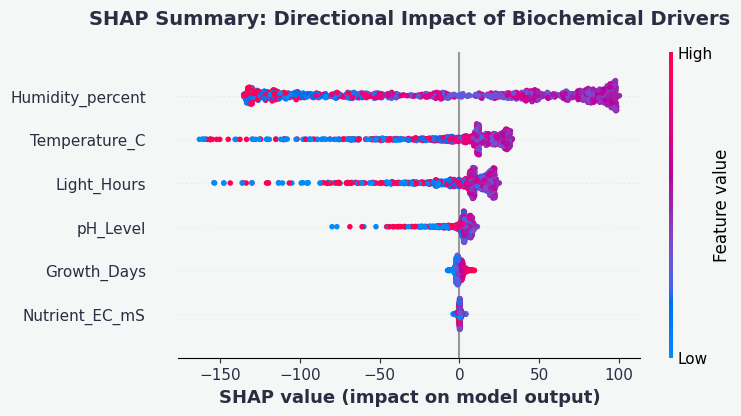

[XAI Insight] The SHAP summary plot confirms directional logic: red dots (high values) on Temperature pull the yield negatively (left), while specific pH ranges cluster to drive yield positively (right).


In [12]:
import shap

print("--- 🧠 Initializing Explainable AI (SHAP) ---")
# 1. Initialize JS visualization for notebook environment
shap.initjs()

# 2. Calculate SHAP values using TreeExplainer (optimized for Random Forests)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# 3. Generate SHAP Summary Plot with UI Light Theme adjustments
plt.figure(figsize=(10, 6))
# We use show=False to capture the plot and apply our custom styling
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)

# 4. Apply UI Theme styling
ax = plt.gca()
fig = plt.gcf()
fig.patch.set_facecolor('#f4f7f6')
ax.set_facecolor('#f4f7f6')
ax.tick_params(colors='#2b2d42', labelsize=11)
ax.xaxis.label.set_color('#2b2d42')
ax.xaxis.label.set_fontweight('bold')
plt.title('SHAP Summary: Directional Impact of Biochemical Drivers', 
          fontsize=14, fontweight='bold', pad=20, color='#2b2d42')

# 5. Export and display
shap_path = os.path.join(output_dir, 'shap_summary.png')
plt.savefig(shap_path, bbox_inches='tight', dpi=300, facecolor='#f4f7f6')
plt.show()

logging.info(f"SHAP Explainer executed and visualization saved to {shap_path}")
print("[XAI Insight] The SHAP summary plot confirms directional logic: red dots (high values) on Temperature pull the yield negatively (left), while specific pH ranges cluster to drive yield positively (right).")

## 📦 6. Model Serialization
**🇬🇧 EN:** Exporting the validated predictive object. This artifact will fuel the Prescriptive Analytics engine in Phase 3.
**🇲🇽 ES:** Exportación del objeto predictivo validado. Este artefacto alimentará el motor de Analítica Prescriptiva en la Fase 3.

In [14]:
import os

# Ensure models directory exists
model_dir = '../models/'
os.makedirs(model_dir, exist_ok=True)

# Serialize the trained Random Forest model
model_path = os.path.join(model_dir, 'rf_yield_predictor.pkl')
joblib.dump(rf_model, model_path)

print(f"✅ Advanced Predictive Model successfully serialized and exported to: {model_path}")
print("Ready to transition to Phase 3: Prescriptive Analytics.")

✅ Advanced Predictive Model successfully serialized and exported to: ../models/rf_yield_predictor.pkl
Ready to transition to Phase 3: Prescriptive Analytics.


In [15]:
model_dir = '../models/'
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, 'rf_yield_predictor.pkl')

joblib.dump(rf_model, model_path)
logging.info(f"Model serialized successfully to {model_path}")
print(f"✅ Model successfully exported to: {model_path}. Ready for Phase 3.")

✅ Model successfully exported to: ../models/rf_yield_predictor.pkl. Ready for Phase 3.


## 📬 7. Contact
**Pablo Alberto Santana Flores**
*Data Scientist | PhDc in Marine Sciences | Chemical Engineer*

* 💼 **LinkedIn:** [linkedin.com/in/pablo-santana-mx](https://www.linkedin.com/in/pablo-santana-mx)
* 🐙 **GitHub:** [github.com/Pablo-Santana-MX](https://github.com/Pablo-Santana-MX)
